In [99]:
import pandas as pd
import re
import spacy
from spacy.tokens import Span
from spacy.pipeline import EntityRuler
from spacy.language import Language
from spacy.util import filter_spans
from thinc.api import prefer_gpu
from collections import Counter
from tqdm import tqdm
import torch

In [59]:
print(torch.cuda.is_available())  # Should be True
print(torch.cuda.get_device_name(0))  # Your GPU


True
Quadro P1000


In [60]:
prefer_gpu() 

False

In [61]:
df_all = pd.read_csv("../data/processed/all_clean_for_ner.csv")

In [62]:
nlp = spacy.load("en_core_web_lg", disable=["tagger","parser","lemmatizer"])

In [63]:
ruler = nlp.add_pipe("entity_ruler", before="ner")

In [64]:
patterns = [

    # -------- SERVICES / PLANS --------
    {"label": "SERVICE", "pattern": [{"LOWER": "data"}, {"LOWER": "plan"}]},
    {"label": "SERVICE", "pattern": [{"LOWER": "internet"}]},
    {"label": "SERVICE", "pattern": [{"LOWER": "broadband"}]},
    {"label": "SERVICE", "pattern": [{"LOWER": "roaming"}]},
    {"label": "SERVICE", "pattern": [{"LOWER": "voicemail"}]},
    {"label": "SERVICE", "pattern": [{"LOWER": "subscription"}]},

    # -------- DEVICES --------
    {"label": "PRODUCT", "pattern": [{"LOWER": "router"}]},
    {"label": "PRODUCT", "pattern": [{"LOWER": "modem"}]},
    {"label": "PRODUCT", "pattern": [{"LOWER": "sim"}, {"LOWER": "card"}]},
    {"label": "PRODUCT", "pattern": [{"LOWER": "iphone"}]},
    {"label": "PRODUCT", "pattern": [{"LOWER": "android"}]},

    # -------- ISSUES / COMPLAINTS --------
    {"label": "ISSUE", "pattern": [{"LOWER": "no"}, {"LOWER": "signal"}]},
    {"label": "ISSUE", "pattern": [{"LOWER": "slow"}, {"LOWER": "internet"}]},
    {"label": "ISSUE", "pattern": [{"LOWER": "network"}, {"LOWER": "outage"}]},
    {"label": "ISSUE", "pattern": [{"LOWER": "dropped"}, {"LOWER": "calls"}]},
    {"label": "ISSUE", "pattern": [{"LOWER": "overcharged"}]},
    {"label": "ISSUE", "pattern": [{"LOWER": "billing"}, {"LOWER": "issue"}]},

    # -------- ACTIONS --------
    {"label": "ACTION", "pattern": [{"LOWER": "reset"}]},
    {"label": "ACTION", "pattern": [{"LOWER": "refund"}]},
    {"label": "ACTION", "pattern": [{"LOWER": "replace"}]},
    {"label": "ACTION", "pattern": [{"LOWER": "upgrade"}]},
    {"label": "ACTION", "pattern": [{"LOWER": "cancel"}]},
    {"label": "ACTION", "pattern": [{"LOWER": "escalate"}]},
]


In [65]:
ruler.add_patterns(patterns)

In [66]:
ACCOUNT_RE = re.compile(r"\b[A-Z]{2,5}-?\d{4,}\b")
PHONE_RE = re.compile(r"\b(\+?\d{1,3}[-.\s]?)?\(?\d{2,4}\)?[-.\s]?\d{3,4}[-.\s]?\d{3,4}\b")

In [67]:
@Language.component("regex_entities")
def add_regex_entities(doc):
    # Start with existing entities
    ents = list(doc.ents)
    
    # Add regex matches
    for match in ACCOUNT_RE.finditer(doc.text):
        span = doc.char_span(match.start(), match.end(), label="ACCOUNT_ID")
        if span:
            ents.append(span)
    for match in PHONE_RE.finditer(doc.text):
        span = doc.char_span(match.start(), match.end(), label="PHONE_NUMBER")
        if span:
            ents.append(span)
    
    # Filter overlapping spans and keep the longest
    doc.ents = filter_spans(ents)
    return doc

In [68]:
if "regex_entities" in nlp.pipe_names:
    nlp.remove_pipe("regex_entities")

nlp.add_pipe("regex_entities", last=True)


<function __main__.add_regex_entities(doc)>

In [69]:
all_entities = []
batch_size = 256

In [70]:
for doc in tqdm(nlp.pipe(df_all["text"].tolist(), batch_size=batch_size, n_process=1)):
    all_entities.append([(ent.text, ent.label_) for ent in doc.ents])

154824it [28:25, 90.78it/s] 


In [104]:
all_ents = [ent for sublist in df_all["entities"] for ent in sublist]

In [105]:
df_entities = pd.DataFrame(all_ents, columns=["text", "label"])

In [106]:
entity_counts = df_entities["label"].value_counts()
print("Counts per entity type:")
print(entity_counts)

Counts per entity type:
label
CARDINAL        43055
PERSON          42413
ORG             28752
DATE            18718
ACTION          18684
SERVICE          5938
WORK_OF_ART      5862
GPE              4669
TIME             4235
PRODUCT          3444
ORDINAL          3032
MONEY            2315
LAW              1749
LOC               593
PERCENT           266
NORP              255
ISSUE             176
FAC               174
EVENT             144
QUANTITY          122
ACCOUNT_ID         99
PHONE_NUMBER       83
LANGUAGE           28
Name: count, dtype: int64


In [107]:
top_n = 10
for label in df_entities["label"].unique():
    print(f"\nTop {top_n} entities for {label}:")
    most_common = df_entities[df_entities["label"] == label]["text"].value_counts().head(top_n)
    print(most_common)


Top 10 entities for ORG:
text
Union Mobile        10207
PIN                  2316
IoT                  1265
Comcast               676
Apple                 650
ETA                   590
Visa                  584
Mastercard            572
American Express      572
Grace Period:**       555
Name: count, dtype: int64

Top 10 entities for PERSON:
text
Profile      330
John         211
XXXXXXX      149
Sarah        112
Bluetooth     63
Don           61
David         59
James         58
Rachel        55
Goode         55
Name: count, dtype: int64

Top 10 entities for DATE:
text
today                    12034
business days              829
the last                   757
monthly                    297
Good day                   233
a great day                229
1234567890                 222
tomorrow                   220
the next business day      168
last week                  160
Name: count, dtype: int64

Top 10 entities for GPE:
text
GB             1269
Japan           200
France        

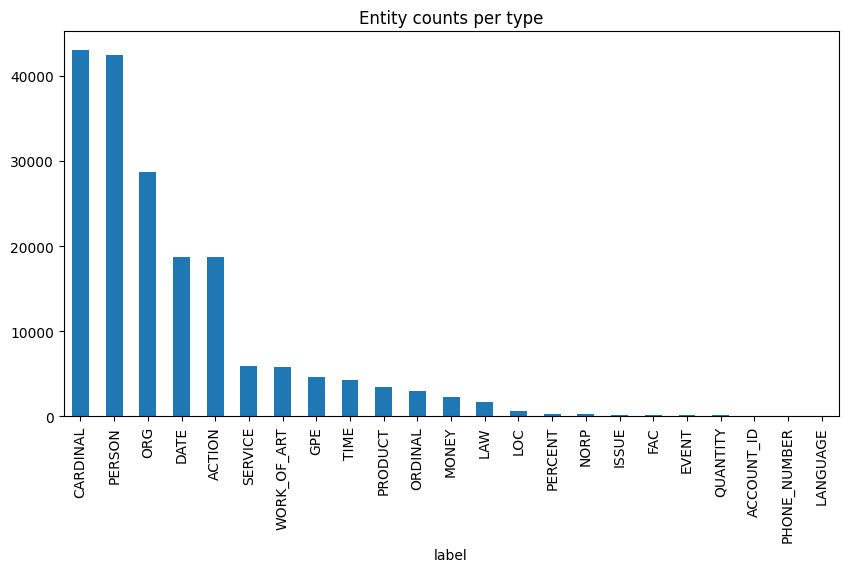

In [109]:
import matplotlib.pyplot as plt
entity_counts.plot(kind="bar", figsize=(10,5), title="Entity counts per type")
plt.show()


In [113]:
df_entities.sample(20)

,text,label
112221,today,DATE
94946,morning,TIME
6793,Guadalupe,PERSON
128817,Apple,ORG
167351,2,CARDINAL
90114,Marlee,PERSON
48071,5,CARDINAL
7842,Union Mobile,ORG
73349,roaming,SERVICE
24464,Geraldine,PERSON


In [114]:
df_entities.to_csv("../data/processed/NER_entities_flattened.csv", index=False)


In [ ]:
df_all.to_csv("../data/processed/all_texts_with_NER_entities.csv", index=False)